# Task 002 - Data Preparation

## CRISP-DM Phase 3

---

# مقدمه

در تسک قبلی شما مرحله **Data Understanding** را روی دیتاست بیماری قلبی انجام دادید.

در پایان آن مرحله باید به درک مناسبی از موارد زیر رسیده باشید:

* ساختار داده
* کیفیت داده
* ویژگی‌های مهم
* ارتباط ویژگی‌ها با متغیر هدف
* مشکلات موجود در داده
* مناسب بودن داده برای مدل‌سازی

اکنون وارد مرحله سوم فرآیند CRISP-DM یعنی **Data Preparation** می‌شویم.

---

# یادآوری چالش کسب‌وکار

شما به عنوان تحلیلگر داده در یک مرکز درمانی قلب و عروق فعالیت می‌کنید.

هدف کسب‌وکار:

تشخیص احتمال ابتلا به بیماری قلبی بر اساس ویژگی‌های بیماران.

متغیر هدف:

```python
target
```

* 0 → Healthy
* 1 → Heart Disease

---

# نوع مسئله داده‌کاوی

با توجه به تحلیل مرحله قبل:

متغیر هدف مشخص است و دو کلاس دارد.

بنابراین مسئله اصلی:

## Supervised Learning

و به طور دقیق‌تر:

## Binary Classification

---

# الگوریتم‌های احتمالی آینده

در مراحل بعدی ممکن است از الگوریتم‌های زیر استفاده شود:

* Logistic Regression
* Decision Tree
* Random Forest
* KNN
* SVM
* Naive Bayes

بنابراین باید داده را به شکلی آماده کنیم که برای این الگوریتم‌ها مناسب باشد.

---

# هدف این تسک

ایجاد یک دیتاست نهایی و آماده برای مرحله Modeling

---

# خروجی نهایی مورد انتظار

در پایان این تسک باید فایل زیر را ایجاد کنید:

```python
heart_prepared.csv
```

این فایل باید:

* تمیز باشد
* ویژگی‌های انتخاب شده را داشته باشد
* ویژگی‌های جدید مورد نیاز را داشته باشد
* فرمت مناسبی داشته باشد
* داده‌های عددی مقیاس‌بندی شده باشند
* برای مدل‌سازی آماده باشد

---

# قوانین

- استفاده از Scikit-Learn ممنوع
- استفاده از AutoML ممنوع


فقط از موارد زیر استفاده شود

- NumPy
- Pandas
- Matplotlib
- Seaborn

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../task_1/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



ویژگی|ترجمه|نوع
|---|---|---|
|age | سن|عددی
|sex |جنسیت|دسته ای
|cp |نوع درد قفسه سینه |دسته ای
|trestbps |فشار خون استراحت|عددی
|chol |کلسترول|عددی
|fbs | قند خون ناشتا|دودویی
|restecg |نوار قلب|دسته ای
|thalach |حداکثر ضربان قلب|عددی
|exang |آنژین ناشی از ورزش|دودویی
|oldpeak |stافت موج |عددی
|slope |شیب قطعه اس تی در ورزش|دسته ای
|ca |تعداد عروق اصلی|دسته ای
|thal |تالاسمی|دسته ای
|target |متغییر هدف |دودویی 

# بخش اول

# Data Selection

---

## سوال 1

براساس تحلیل مرحله قبل:

کدام ستون‌ها بیشترین ارتباط را با target داشتند؟

فهرست آن‌ها را استخراج کنید.

---

In [2]:
corr_with_target = df.corr(numeric_only=True)["target"].sort_values(ascending=False)
print(corr_with_target)

top_features = corr_with_target.drop("target").abs().sort_values(ascending=False)
print("\nmost important features (absolute values):")
print(top_features)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64

most important features (absolute values):
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


ghavi tarin ravabet: exang, cp & oldpeak.
chon faghat be meghdare hambastegi niaz darim, absolute migirim. 

baazi vaghta vaghti field ha teedadeshun ziade bayad hazfeshun konim ke nesbate field be record avaz nashe


## سوال 2

یک جدول تهیه کنید:

---



| Feature | Business Importance | Data Importance(corr) | analysis |
| ------- | ------------------- | --------------- | -------- |
| cp | Very high — Chest pain type is one of the most direct clinical indicators |	High (0.434) |Consistent — Clinical and statistical importance agree|
| thalach | High — Maximum heart rate achieved during exercise | High (0.422) | Consistent |
| oldpeak | High — ST depression on ECG, a strong diagnostic indicator | High (0.431) | Consistent |
| exang	| High — Exercise-induced angina | High (0.437) | Consistent |
| ca | High — Number of major vessels colored by fluoroscopy | High (0.392)	| Consistent |
| thal | High — Thallium stress test result	| Moderate (0.344) | Fairly consistent |
| chol | High — Cholesterol is a classic medical risk factor | Low (0.085) | Inconsistent — Clinically important, but shows weak correlation in this dataset |
| trestbps | High — Resting blood pressure | Low (0.145) | Partially inconsistent |
| fbs | Moderate — Fasting blood sugar | Very low (0.028) | Inconsistent — Medically important, but has little predictive value in this dataset | 
| age | High — Age is an important risk factor | Moderate (0.225) | Fairly consistent |


*included research*

## سوال 3

حداقل سه ویژگی را انتخاب کنید که احتمال می‌دهید برای مدل‌سازی مفید نباشند.

دلایل خود را بنویسید.

---

In [3]:
for col in ["fbs", "chol", "restecg"]:
    print(col, "-> correlation with target:", abs(df[col].corr(df["target"])))

fbs -> correlation with target: 0.028045760272712838
chol -> correlation with target: 0.08523910513756908
restecg -> correlation with target: 0.13722950287377303


fbs: 0.028 correlation ba target. kamtarin meghdar dar kole dataset. in sotun taghriban hich etelaate tamayoz dahandeii beine afrade salem va bimar eraee nemide. hamchenin be dalile mahiate binary va skewness shadid, toziie besiar asymetric y dare.

chol: 0.085 correlation ba target. ba vojood inke az lahaze pezeshki amele mohemie, vali tooye in dataset rabete zaiifi dare ba target. toziie in sotun ham daraye skewness ziad va outlier ziade. 

restECG: 0.137 correlation ba target. in sotun faghat se meghdare 0, 1 va 2 dare va toziiesh besiar asymmetric e. aksare bimara meghdare 0 ya 1 daran. pas ghodrate tamayoz mahdoodi dare. 


## سوال 4

یک نسخه جدید از دیتاست بسازید که فقط شامل ویژگی‌های منتخب شما باشد.

نام:

```python
selected_df
```

---

In [4]:
selected_columns = ["age", "sex", "cp", "trestbps", "thalach", "slope", "exang", "oldpeak", "ca", "thal", "target"]

selected_df = df[selected_columns].copy()
selected_df.head()

,age,sex,cp,trestbps,thalach,slope,exang,oldpeak,ca,thal,target
0,63,1,3,145,150,0,0,2.3,0,1,1
1,37,1,2,130,187,0,0,3.5,0,2,1
2,41,0,1,130,172,2,0,1.4,0,2,1
3,56,1,1,120,178,2,0,0.8,0,2,1
4,57,0,0,120,163,2,1,0.6,0,2,1


ba tavajoh be soalate ghabl, sotun haye chol, fbs، restecg va slope az dataset hazf shodan.


## سوال 5

تعداد ویژگی‌ها قبل و بعد از Selection را مقایسه کنید.

---

In [5]:
print("before selection: ", df.shape[1])
print("after selection: ", selected_df.shape[1])
print("deleted cols: ", df.shape[1] - selected_df.shape[1])
print("percentage removed: ", (df.shape[1] - selected_df.shape[1]) / df.shape[1] * 100)

before selection:  14
after selection:  11
deleted cols:  3
percentage removed:  21.428571428571427


# بخش دوم

# Data Cleaning

---

## سوال 6

تمام مقادیر Null را مجدداً بررسی کنید.

---

In [6]:
print(selected_df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
thalach     0
slope       0
exang       0
oldpeak     0
ca          0
thal        0
target      0
dtype: int64


## سوال 7

برای هر ستون مشخص کنید:

* تعداد Null
* درصد Null

---

In [7]:
null_count = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

print(null_count, null_percent)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64 age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64


## سوال 8

اگر داده گمشده وجود دارد:

سه روش مختلف برای پر کردن آن پیشنهاد دهید.

---

Mean/Median Imputation: baraye sotun hate numerical continious mesle trestbps & thalach, Median behtar az mean ast chon in sotun ha Outlier daran va agar mean begirim be samte outlier keshide mishe. 

Mode Imputation: baraye cp, thal va ca, ba por tekrar tarin maghadir por mishe chon fasele beine maghadire in sotun ha maanaye riazi nadaran.

Group-based Imputation: bejaye inke bar asase kole dataset missing value haro por konim, bar asase dade (record) haye moshabeh inkaro mikonim. aval dataset ro group bandi mikonim bar asase sotun haye dige, baad frequent tarin category ro tuye oon group peyda mikonim o bejaye missing value mizarim.
baraye sotun haye categorical estefade mishe.

## سوال 9

یکی از روش‌ها را انتخاب کرده و پیاده‌سازی کنید.

---

In [8]:
print("before:")
print(df.isnull().sum())

df.fillna(df.median(numeric_only=True), inplace=True)

print("\nafter:")
print(df.isnull().sum())

before:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

after:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


chon maghadire null nadarim be karemoon nemiad. 

## سوال 10

رکوردهای تکراری را شناسایی کنید.

---

In [9]:
duplicate_count = df.duplicated().sum()
print("duplicated values: ", duplicate_count)

duplicated values:  1


## سوال 11

نسخه‌ای از داده بدون رکوردهای تکراری ایجاد کنید.

---

In [10]:
df_no_duplicates = df.drop_duplicates().reset_index(drop=True)

## سوال 12

با استفاده از Boxplot و IQR:

Outlier های هر ویژگی عددی را پیدا کنید.

---

#### categorical ها رو چیکار کنیم ؟؟؟؟؟؟؟؟؟

{'age': 0, 'trestbps': 9, 'chol': 5, 'thalach': 1, 'oldpeak': 5}


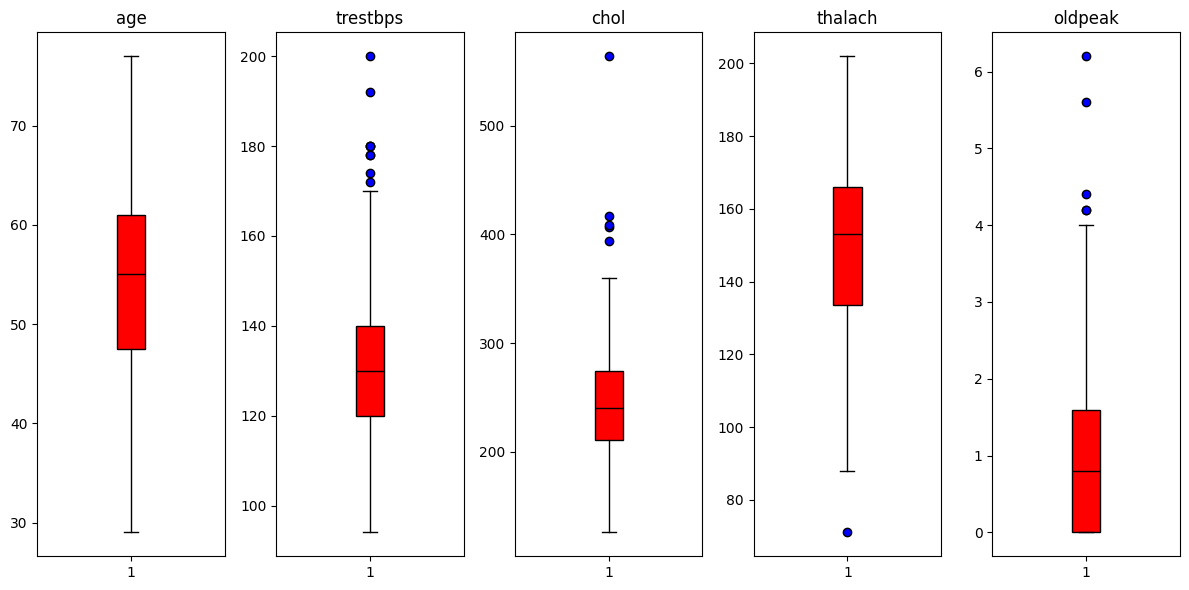

In [11]:
col = []
for index in df.columns:
    unique_number = df[index].nunique()
    if unique_number > 6:
        col.append(index)
fig , ax = plt.subplots(figsize=(12,6),ncols=len(col))
for i ,column in enumerate(col):
    ax[i].boxplot(df[column],patch_artist=True,boxprops={"facecolor":"red"},medianprops={"color":"black"},flierprops={"markerfacecolor":"blue"})
    ax[i].set_title(column)
plt.tight_layout()


outlier_info = {}
for feature in col:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_info[feature] = len(outliers)

print(outlier_info)


## سوال 13

جدولی ایجاد کنید:

| Feature | Number of Outliers |

---

In [12]:
outlier_table = pd.DataFrame(outlier_info.items(), columns=["Feature", "No of Outliers"])
print(outlier_table)

    Feature  No of Outliers
0       age               0
1  trestbps               9
2      chol               5
3   thalach               1
4   oldpeak               5


## سوال 14

برای Outlier ها سه استراتژی مختلف پیشنهاد دهید.

---

multi dimentional 
one directional (normal distribution...)

quarts (putting third quantile or first quantile instead)



1. univariate (capping/winsorizing): har sotun ro barresi mikone va outlier IQR ro be Q3 va Q1 mahdood mikone. (relationship dar nazar nemigire)

2. univariate (removing record): recordaii ke value kharej az IQR darano delete mikone. (baraye vaghti ke motmaenim outlier khataye sabte na variance tabii).

    *age 9 recordo hazf konim (3%), riske kaheshe ghodrate amari modelo dare*
    
3. multivariate (combined IQR): chand sotun hamzaman barresi mikone. recordi outlier mahsoob mishe ke tooye bish az 1 sotun hamzaman meghdare outlier dashe bashe. (olgoo haye gheire tabii combination ro shenasaii mikone ke univariate nemikone).

## سوال 15

یک استراتژی را انتخاب و پیاده‌سازی کنید.

---

In [13]:

for feature in col:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[feature] = np.clip(df[feature], lower_bound, upper_bound)

outlier_info = {}

for feature in col:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_info[feature] = len(outliers)

print("Outliers after capping:")
print(outlier_info)

Outliers after capping:
{'age': 0, 'trestbps': 0, 'chol': 0, 'thalach': 0, 'oldpeak': 0}


# بخش سوم

# Data Construction

---

در این بخش باید ویژگی‌های جدید ایجاد شوند.

---

## سوال 16

سن را به سه گروه تقسیم کنید:

* Young
* Middle Age
* Senior

ستون جدید:

```python
age_group
```

---

In [14]:
def age_to_group(age):
    if age < 40:
        return "Young"
    elif age < 55:
        return "Middle Age"
    else:
        return "old"

df["age_group"] = df["age"].apply(age_to_group)
df[["age", "age_group"]].head(10)

,age,age_group
0,63,old
1,37,Young
2,41,Middle Age
3,56,old
4,57,old
5,57,old
6,56,old
7,44,Middle Age
8,52,Middle Age
9,57,old


## سوال 17

برای chol سطح ریسک ایجاد کنید:

* Low
* Normal
* High

---

In [15]:
def chol_to_level(chol):
    if chol < 200:
        return "low"
    elif chol < 240:
        return "Normal"  
    else:
        return "High"

df["chol_level"] = df["chol"].apply(chol_to_level)
df[["chol", "chol_level"]].head(10)

,chol,chol_level
0,233.0,Normal
1,250.0,High
2,204.0,Normal
3,236.0,Normal
4,354.0,High
5,192.0,low
6,294.0,High
7,263.0,High
8,199.0,low
9,168.0,low


## سوال 18

برای trestbps سطح فشار خون تعریف کنید.

---

In [16]:
def bp_to_level(bp):
    if bp < 120:
        return "Normal"
    elif bp < 140:
        return "Elevated"
    else:
        return "High"

df["bp_level"] = df["trestbps"].apply(bp_to_level)
df[["trestbps", "bp_level"]].head(30)

,trestbps,bp_level
0,145,High
1,130,Elevated
2,130,Elevated
3,120,Elevated
4,120,Elevated
5,140,High
6,140,High
7,120,Elevated
8,170,High
9,150,High


## سوال 19

حداقل دو Feature جدید طراحی کنید.

دلایل کسب‌وکاری آن را توضیح دهید.

---

In [17]:
df["hr_age_ratio"] = df["thalach"] / df["age"]
df["risk_factor_count"] = (
    (df["chol_level"] == "High").astype(int) +
    (df["bp_level"] == "High").astype(int) +
    (df["fbs"] == 1).astype(int) +
    (df["exang"] == 1).astype(int)
)

df[["hr_age_ratio", "risk_factor_count"]].head(10)

,hr_age_ratio,risk_factor_count
0,2.380952,2
1,5.054054,1
2,4.195122,0
3,3.178571,0
4,2.859649,2
5,2.596491,1
6,2.732143,2
7,3.931818,1
8,3.115385,2
9,3.052632,1


zaraban ghalbe normal ro barresi mikonim ke bebinim bar asase senesh zaraban ghalbe tabii dare ya na.
vizheghi dovom baraye model haye khati ke taamol beine vizhegi haro be khoobi nemibinan be kar miad.

## سوال 20

جدول زیر را تکمیل کنید:

| New Feature | Business Reason |

---

| **New Feature** | **Business Rationale** | **Type** |
| -------------------- | ------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------- |
| **age_group** | Simplifies clinical interpretation and group-based analysis. Physicians typically make decisions based on age groups rather than exact age. | Categorical (derived from a numerical feature) |
| **chol_level** | Maps raw cholesterol values to standard NIH/AHA cholesterol categories, making the feature directly interpretable by clinicians. | Categorical (derived from a numerical feature) |
| **bp_level** | Applies the same concept to blood pressure, enabling quick identification of patients in clinically high-risk categories. | Categorical (derived from a numerical feature) |
| **hr_age_ratio** | Represents relative cardiovascular capacity by combining maximum heart rate and age into a meaningful physiological indicator. | Derived numerical feature |
| **multi_risk_score** | Aggregates multiple risk factors into a single score, which can improve the performance and interpretability of linear models. | Numerical (count/score) |


# بخش چهارم

# Data Integration

---

فرض کنید داده جدیدی از آزمایشگاه دریافت شده است.

فایل فرضی:

```python
lab_results.csv
```

---

## سوال 21

یک DataFrame آزمایشی بسازید.

---

In [18]:
np.random.seed(42)

lab_results = pd.DataFrame({
    "patient_id": np.arange(1, len(df) + 1),
    "glucose_level": np.random.normal(100, 15, len(df)).round(1),
    "creatinine": np.random.normal(1.0, 0.2, len(df)).round(2)
})

lab_results.head(10)

,patient_id,glucose_level,creatinine
0,1,107.5,1.12
1,2,97.9,1.00
2,3,109.7,1.02
3,4,122.8,1.26
4,5,96.5,0.88
5,6,96.5,1.11
6,7,123.7,0.96
7,8,111.5,0.96
8,9,93.0,1.22
9,10,108.1,1.17


## سوال 22

یک کلید مشترک تعریف کنید.

---

In [19]:
df_with_id = df.reset_index(drop=True).copy()
df_with_id["patient_id"] = np.arange(1, len(df_with_id) + 1)

common_key = "patient_id"
print(" common key:", common_key)
print("unique?",
      df_with_id[common_key].is_unique, lab_results[common_key].is_unique)

lab_results


 common key: patient_id
unique? True True


,patient_id,glucose_level,creatinine
0,1,107.5,1.12
1,2,97.9,1.00
2,3,109.7,1.02
3,4,122.8,1.26
4,5,96.5,0.88
...,...,...,...
298,299,112.2,0.82
299,300,109.4,1.17
300,301,87.6,1.27
301,302,91.6,1.08


## سوال 23

Merge را انجام دهید.

---

In [20]:
merged_df = pd.merge(df_with_id, lab_results, on="patient_id", how="left")
merged_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,thal,target,age_group,chol_level,bp_level,hr_age_ratio,risk_factor_count,patient_id,glucose_level,creatinine
0,63,1,3,145,233.0,1,0,150.0,0,2.3,...,1,1,old,Normal,High,2.380952,2,1,107.5,1.12
1,37,1,2,130,250.0,0,1,187.0,0,3.5,...,2,1,Young,High,Elevated,5.054054,1,2,97.9,1.00
2,41,0,1,130,204.0,0,0,172.0,0,1.4,...,2,1,Middle Age,Normal,Elevated,4.195122,0,3,109.7,1.02
3,56,1,1,120,236.0,0,1,178.0,0,0.8,...,2,1,old,Normal,Elevated,3.178571,0,4,122.8,1.26
4,57,0,0,120,354.0,0,1,163.0,1,0.6,...,2,1,old,High,Elevated,2.859649,2,5,96.5,0.88


## سوال 24

انواع Merge زیر را مقایسه کنید:

* inner
* left
* right
* outer

---

inner: only records with matching keys in both tables. used when missing data is not acceptable and only matching records are needed.

left: all records from the left (primary) table. used When the primary table must be preserved completely, even if some records have no match.

right: all records from the right (secondary) table. used When the secondary table is the main source of data and must be preserved completely.

outer: all records from both tables. When no records should be lost, regardless of whether a match exists in the other table.


In [21]:
# inner_merge = pd.merge(df_with_id, lab_results, on="patient_id", how="inner")
# outer_merge = pd.merge(df_with_id, lab_results, on="patient_id", how="outer")
# print(inner_merge.shape, outer_merge.shape)

## سوال 25

مشخص کنید برای این پروژه کدام نوع Merge مناسب‌تر است.

---

left merge

chon be hameye dataye bimara niaz darim chon teedade recordamoon kaman. lab_results naghshe takmili dare, manteghi nist bekhatere naboodane natike azmayesh record asli ro pak konim (target mootabar). 

# بخش پنجم

# Data Formatting

---

## سوال 26

نوع داده تمامی ستون‌ها را بررسی کنید.

---

In [22]:
print(df.dtypes)
df.info()

age                    int64
sex                    int64
cp                     int64
trestbps               int64
chol                 float64
fbs                    int64
restecg                int64
thalach              float64
exang                  int64
oldpeak              float64
slope                  int64
ca                     int64
thal                   int64
target                 int64
age_group             object
chol_level            object
bp_level              object
hr_age_ratio         float64
risk_factor_count      int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                303 non-null    int64  
 1   sex                303 non-null    int64  
 2   cp                 303 non-null    int64  
 3   trestbps           303 non-null    int64  
 4   chol               303 non-null    fl

## سوال 27

ستون‌هایی که باید Category باشند را شناسایی کنید.

---

In [23]:
categorical_candidates = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]
for col in categorical_candidates:
    values = sorted(df[col].astype(int).unique().tolist())
    print(col, "-> no. of unique values:", df[col].nunique(), "| values:", values)

sex -> no. of unique values: 2 | values: [0, 1]
cp -> no. of unique values: 4 | values: [0, 1, 2, 3]
fbs -> no. of unique values: 2 | values: [0, 1]
restecg -> no. of unique values: 3 | values: [0, 1, 2]
exang -> no. of unique values: 2 | values: [0, 1]
slope -> no. of unique values: 3 | values: [0, 1, 2]
ca -> no. of unique values: 5 | values: [0, 1, 2, 3, 4]
thal -> no. of unique values: 4 | values: [0, 1, 2, 3]
target -> no. of unique values: 2 | values: [0, 1]


## سوال 28

Datatype مناسب را اعمال کنید.

---

In [24]:
df_changed = df.copy()
for col in categorical_candidates:
    df_changed[col] = df_changed[col].astype("category")
print(df_changed.dtypes)

age                     int64
sex                  category
cp                   category
trestbps                int64
chol                  float64
fbs                  category
restecg              category
thalach               float64
exang                category
oldpeak               float64
slope                category
ca                   category
thal                 category
target               category
age_group              object
chol_level             object
bp_level               object
hr_age_ratio          float64
risk_factor_count       int64
dtype: object


## سوال 29

حجم حافظه قبل و بعد از تغییر datatype را مقایسه کنید.

---

In [25]:
memory_before = df.memory_usage(deep=True).sum()
memory_after = df_changed.memory_usage(deep=True).sum()
print(f"before: {memory_before / 1024:.2f} KB")
print(f"after:  {memory_after / 1024:.2f} KB")
print(f"percentage changed: {(1 - memory_after/memory_before) * 100:.2f}%")

before: 93.59 KB
after:  76.30 KB
percentage changed: 18.48%


category -> int8

## سوال 30

ستون‌های متنی را استانداردسازی کنید.

مثال:

```python
Male
male
MALE
```

---

In [26]:
text_columns = df_changed.select_dtypes(include="object").columns
for col in text_columns:
    df_changed[col] = df_changed[col].str.strip().str.lower()


# بخش ششم

# Data Reduction

---

## سوال 31

ویژگی‌های دارای واریانس بسیار کم را شناسایی کنید.

---

In [27]:
# numeric_df = df.select_dtypes(include=[np.number])
# variances = numeric_df.var().sort_values()
# print(variances)
# print(variances[variances < 0.05])

## سوال 32

ویژگی‌های بسیار همبسته را شناسایی کنید.

---

In [28]:
corr_matrix = df.select_dtypes(exclude="object").corr()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr = corr_matrix.iloc[i, j]
        if corr > 0.55:
            print(corr_matrix.index[i], "-", corr_matrix.columns[j], ":", round(corr, 3))

thalach - hr_age_ratio : 0.782
exang - risk_factor_count : 0.574


## سوال 33

Heatmap جدید رسم کنید.

---

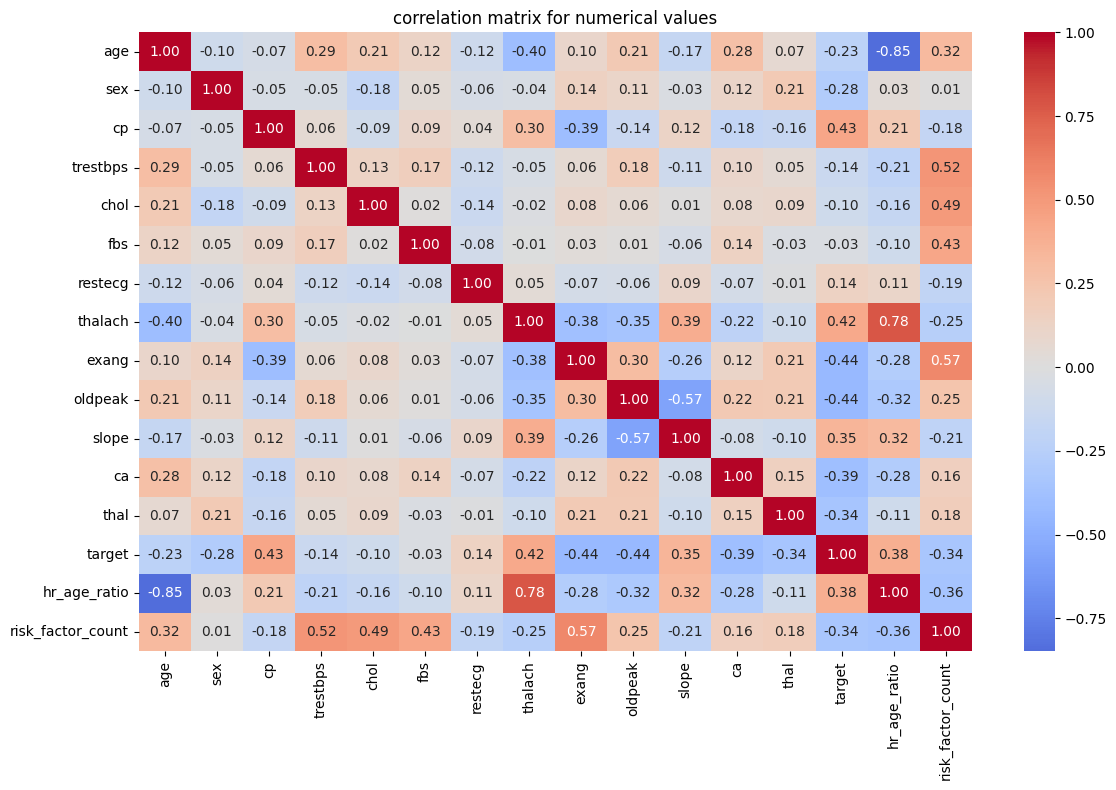

In [29]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0) 
plt.title("correlation matrix for numerical values") 
plt.tight_layout()
plt.show()

## سوال 34

اگر دو ویژگی همبستگی بالای 0.85 دارند:

کدام را حذف می‌کنید؟

چرا؟

---

agar hambastegi do vizhegi az 0.85 balatar bashad yaani etelaate besiar moshabehi erae midan va negah dashtan har do vizhegi baeese redundancy dade ha va kaheshe karaii baazi az model haye ML mishe.
vizhegii ke ertebate kamtari ba target dare remove mishe. age hardo ertebate yeksani ba target dashte bashan, vizhegii ke as nazare business understanding ahamiate kamtari dare delete mishe. 
agar ham missing value tooye yeki az sotuna bishtar bashe oon delete mishe. 

## سوال 35

یک نسخه کاهش‌یافته از دیتاست ایجاد کنید.

نام:

```python
reduced_df
```

---

In [30]:
# columns_to_drop = ["chol", "fbs", "restecg", "slope"]
# reduced_df = df.drop(columns=columns_to_drop).copy()
# print("shape selected_df:", df_changed.shape)
# print("shape reduced_df:", reduced_df.shape)

# بخش هفتم

# Data Transformation

---

# Normalization & Scaling

---

## سوال 36

بررسی کنید آیا ویژگی‌های عددی مقیاس‌های متفاوت دارند یا خیر.

---

In [44]:
print(df_changed.select_dtypes(exclude="category").describe().T[["min","max","std"]])

                          min         max        std
age                 29.000000   77.000000   9.082101
trestbps            94.000000  170.000000  16.582241
chol               126.000000  369.750000  47.552910
thalach             84.750000  202.000000  22.762004
oldpeak              0.000000    4.000000   1.110127
hr_age_ratio         1.264925    6.965517   0.831393
risk_factor_count    0.000000    4.000000   0.977318


bale. Tooye algorithm haii mesle KNN, dade haii ba scaling bishtar az dade haii ba scaing kamtar bishtar asar mizaran.

## سوال 37

برای تمام ویژگی‌های عددی:

Min-Max Scaling را با NumPy پیاده‌سازی کنید.

فرمول:

```python
(x-min)/(max-min)
```

---

In [45]:
numeric_cols = ["age", "trestbps", "thalach", "oldpeak"]
df_minmax = df.copy()
df_minmax[numeric_cols] = (df_minmax[numeric_cols] - df_minmax[numeric_cols].min()) / (df_minmax[numeric_cols].max() - df_minmax[numeric_cols].min())
print(df_minmax[numeric_cols].describe().T[["min", "max", "mean"]])

          min  max      mean
age       0.0  1.0  0.528465
trestbps  0.0  1.0  0.490533
thalach   0.0  1.0  0.553878
oldpeak   0.0  1.0  0.256106


## سوال 38

برای تمام ویژگی‌های عددی:

Standardization را با NumPy پیاده‌سازی کنید.

---

In [52]:
df_standard = df.copy()
df_standard[numeric_cols] = (df_standard[numeric_cols] - df_standard[numeric_cols].mean()) / df_standard[numeric_cols].std()
print(df_standard[numeric_cols].describe().T[["mean", "std"]])

                  mean  std
age       7.035077e-17  1.0
trestbps -8.442092e-16  1.0
thalach   1.407015e-16  1.0
oldpeak   1.641518e-16  1.0


## سوال 39

قبل و بعد از Scaling:

Histogram رسم کنید.

---

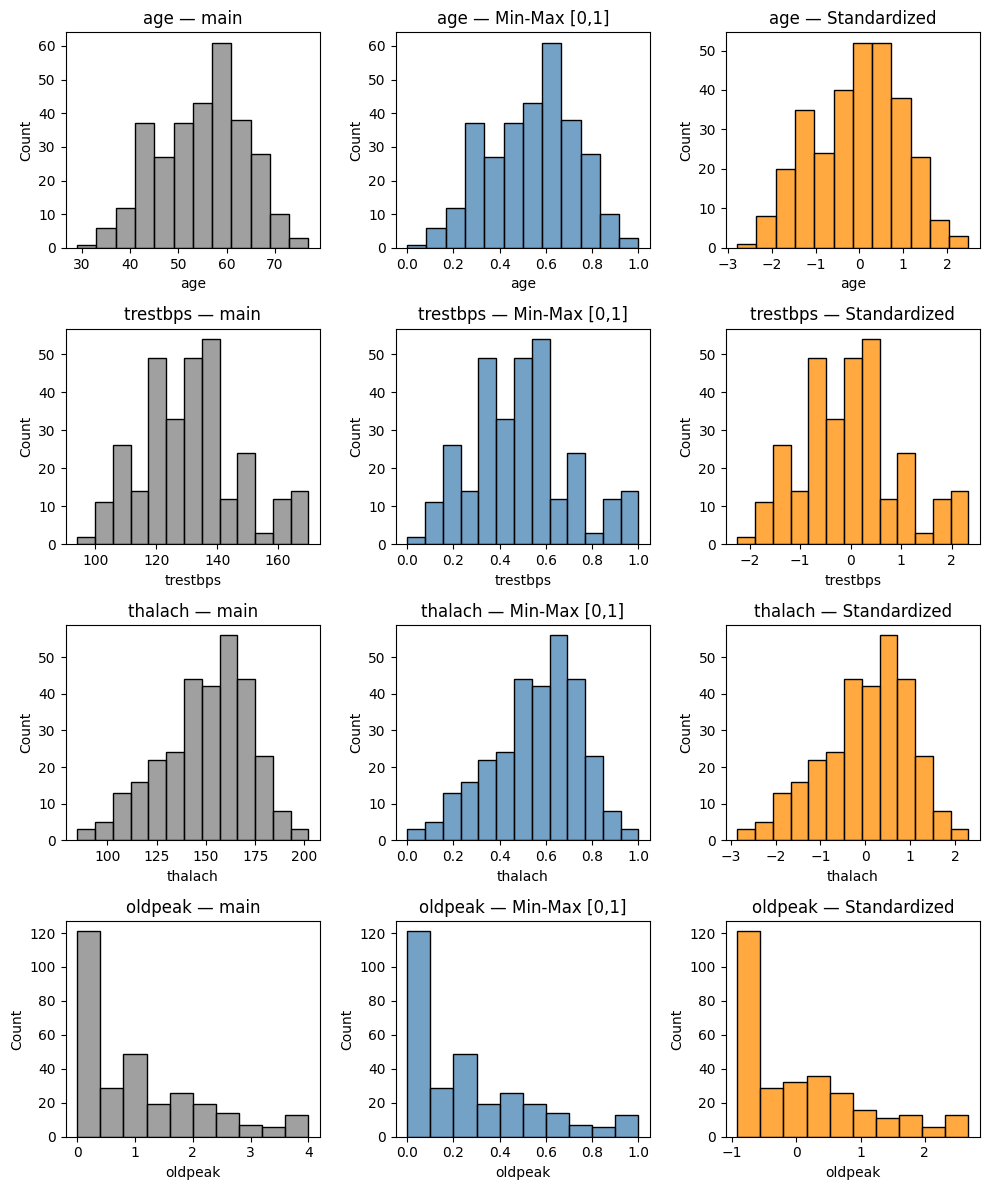

In [57]:
fig, axes = plt.subplots(len(numeric_cols), 3, figsize=(10, 3*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax=axes[i,0], color="gray")
    axes[i,0].set_title(f"{col} — main")

    sns.histplot(df_minmax[col], ax=axes[i,1], color="steelblue")
    axes[i,1].set_title(f"{col} — Min-Max [0,1]")

    sns.histplot(df_standard[col], ax=axes[i,2], color="darkorange")
    axes[i,2].set_title(f"{col} — Standardized")

plt.tight_layout()
plt.show()

## سوال 40

مقایسه کنید:

* MinMax
* Standardization

برای این پروژه کدام مناسب‌تر است؟

---

# بخش هشتم

# Dataset Validation

---

## سوال 41

شکل نهایی دیتاست را گزارش کنید.

---

In [31]:
final_df = df_standard.copy()  # یا هر نسخه نهایی که انتخاب کرده‌اید
print("شکل نهایی دیتاست:", final_df.shape)
print("ستون‌ها:", list(final_df.columns))

NameError: name 'df_standard' is not defined

## سوال 42

آیا Null باقی مانده است؟

---

In [ ]:
remaining_nulls = final_df.isnull().sum().sum()
print("تعداد Null باقیمانده:", remaining_nulls)
assert remaining_nulls == 0, "هنوز مقادیر Null وجود دارد!"

تعداد Null باقیمانده: 0


## سوال 43

آیا Duplicate باقی مانده است؟

---

In [ ]:
# remaining_duplicates = final_df.duplicated().sum()
# print("تعداد رکورد تکراری باقیمانده:", remaining_duplicates)
# assert remaining_duplicates == 0, "هنوز رکورد تکراری وجود دارد!"

## سوال 44

آیا Outlier ها مدیریت شده‌اند؟

---

In [ ]:
for col in numeric_cols_final:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    remaining_outliers = final_df[(final_df[col] < lower_bound) | (final_df[col] > upper_bound)]
    print(f"{col}: {len(remaining_outliers)} outlier باقیمانده")

age: 0 outlier باقیمانده
sex: 0 outlier باقیمانده
cp: 0 outlier باقیمانده
trestbps: 9 outlier باقیمانده
thalach: 1 outlier باقیمانده
slope: 0 outlier باقیمانده
exang: 0 outlier باقیمانده
oldpeak: 5 outlier باقیمانده
ca: 25 outlier باقیمانده
thal: 2 outlier باقیمانده


## سوال 45

آیا تمامی ویژگی‌ها فرمت مناسبی دارند؟

---

In [ ]:
print(final_df.dtypes)
print("\nستون‌های غیرعددی (که باید encode شوند قبل از مدل‌سازی):")
print(final_df.select_dtypes(exclude=[np.number]).columns.tolist())

age         float64
sex         float64
cp          float64
trestbps    float64
thalach     float64
slope       float64
exang       float64
oldpeak     float64
ca          float64
thal        float64
target        int64
dtype: object

ستون‌های غیرعددی (که باید encode شوند قبل از مدل‌سازی):
[]


## سوال 46

آیا داده برای KNN مناسب است؟

توضیح دهید.

---

## سوال 47

آیا داده برای Logistic Regression مناسب است؟

توضیح دهید.

---

## سوال 48

آیا داده برای Decision Tree مناسب است؟

توضیح دهید.

---

## سوال 49

دیتاست نهایی را ذخیره کنید:

```python
heart_prepared.csv
```

---

## سوال 50

یک گزارش مدیریتی تهیه کنید.

به سوالات زیر پاسخ دهید:

1. چه تغییراتی روی داده انجام شد؟
2. چه ویژگی‌هایی حذف شدند؟
3. چه ویژگی‌هایی ساخته شدند؟
4. چه مشکلاتی برطرف شد؟
5. آیا داده برای Modeling آماده است؟

---

# تحویل پروژه

فایل‌های زیر باید ارسال شوند:

```python
task002_data_preparation.ipynb
heart_prepared.csv
```

---

# هدف آموزشی این تسک

پس از پایان این تمرین دانشجو باید بتواند:

✅ Data Selection انجام دهد

✅ Data Cleaning انجام دهد

✅ Feature Construction انجام دهد

✅ Data Integration انجام دهد

✅ Data Formatting انجام دهد

✅ Data Reduction انجام دهد

✅ Scaling و Normalization انجام دهد

✅ یک دیتاست خام را به یک دیتاست آماده مدل‌سازی تبدیل کند

این دقیقاً خروجی مورد انتظار مرحله Data Preparation در فرآیند CRISP-DM است.